# CNNs and Computer Vision — code examples

> **BWXT Data Science Workforce Training Pilot**  
> Companion to `Chapter_CNNs_Computer_Vision.md`

**How to use this notebook**

1. Run cells **top to bottom** the first time through.
2. Read each **markdown** cell before the **code** cell below it — those notes explain what you are about to run and what to look for in the output.
3. **Setup** must run before convolution and pooling (it creates `mnist_digit_28x28` and `mnist_label`).

**Prerequisites:** For perceptrons, activations, losses, and gradient descent, see `../Introduction_Neural_Networks/Chapter_Introduction_to_Neural_Networks_Code_Examples.ipynb`.

**Libraries here:** `torch`, `torchvision` (MNIST), `numpy`, `scipy`, `matplotlib`.

**Sections in this notebook:** Setup → image sizes → filters & transforms → pooling → task types → architecture tradeoffs → workflow → TinyCNN → transfer learning (ResNet).


## Setup (run first)

**What this does:** Downloads MNIST if needed (into `./data`) and loads **one training image** — sample index `0`.

**Variables you need later:**

| Variable | Meaning |
| -------- | ------- |
| `mnist_digit_28x28` | Nested lists, 28 rows × 28 columns, pixel values **0–255** |
| `mnist_label` | Digit class (0–9) for that image |

Convolution and pooling sections use this same digit so results stay comparable.

In [166]:
import math
from pprint import pprint

import torch
from torchvision import datasets, transforms

_mnist = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transforms.ToTensor(),
)
_img, mnist_label = _mnist[0]

_full = _img[0] * 255.0
mnist_digit_28x28 = _full.round().to(torch.int).tolist()

print('Setup complete.')
print(f'MNIST sample index 0, label={mnist_label}, shape 28×28')

Setup complete.
MNIST sample index 0, label=5, shape 28×28


## Image size examples

Images are **grids of numbers**. Total pixel count grows quickly with height, width, and channel count. These two cells mirror the chapter’s **224×224** examples for grayscale vs RGB.

### Grayscale image (1 channel)

**Shape:** `(height, width, channels)` → `(224, 224, 1)`  
**Pixel count:** height × width × channels = **50,176**

No color — one intensity per pixel. Many inspection cameras or X-ray-style views are single-channel.

In [167]:
height = 224
width = 224
channels = 1

grayscale_pixel_count = height * width * channels
print('Grayscale image shape:', (height, width, channels))
print('Pixel values:', grayscale_pixel_count)

Grayscale image shape: (224, 224, 1)
Pixel values: 50176


### Color image (3 channels)

**Shape:** `(224, 224, 3)` for RGB  
**Pixel count:** **150,528** (three times the grayscale count at the same resolution)

Each pixel has red, green, and blue values. CNNs still use tensors, often **N×C×H×W** in PyTorch (batch, channels, height, width).

In [168]:
height = 224
width = 224
channels = 3

color_pixel_count = height * width * channels
print('Color image shape:', (height, width, channels))
print('Pixel values:', color_pixel_count)

Color image shape: (224, 224, 3)
Pixel values: 150528


## Convolutional filters and feature maps

**Needs:** Setup (`mnist_digit_28x28`, `mnist_label`).

**Key idea:** A **3×3 filter** slides over the image. At each position, multiply overlapping pixels by filter weights and **sum** → one number in the **feature map**.

| Term | Meaning |
| ---- | ------- |
| **Filter / kernel** | Small weight pattern (here: hand-designed, not learned yet) |
| **Feature map** | Output grid after applying one filter |
| **Valid convolution** | No padding → **28×28** input + **3×3** kernel → **26×26** output |

**Hand-designed vs learned:** This cell uses **fixed** edge/blur/sharpen/Laplacian stencils so you can *see* the math. In a trained CNN, **`Conv2d` weights are learned** during training — the plots below are **not** those learned weights; they show how different stencils respond to the same digit.

### Simple image transforms

Before hand-designed filters, two quick operations show that not every image step is convolution. **Brightness** changes pixel values in place; **flipping** rearranges pixels without blending neighbors.


### Brightness adjustment

**Needs:** Setup (`mnist_digit_28x28`). The SciPy filters cell below imports `matplotlib.pyplot as plt` if you have not run it yet.

**What this does:** Adds a constant (+20) to every pixel — a **point operation** that does not mix neighboring pixels.

**What to notice:** The digit looks lighter, but edge locations stay the same. Real pipelines often normalize brightness before feeding images to a CNN.


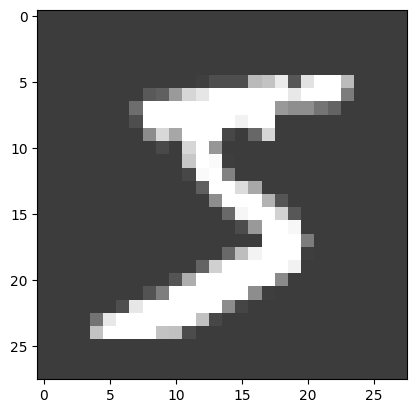

In [178]:
import numpy as np
import matplotlib.pyplot as plt

# make image brighter
mnist_digit_28x28_bright = np.array(mnist_digit_28x28) + 20
# show the image
plt.imshow(mnist_digit_28x28_bright, cmap='gray', vmin=0, vmax=255)
plt.show()


### Horizontal flip

**Needs:** Setup (`mnist_digit_28x28`).

**What this does:** Mirrors the image left-to-right with `np.flip(..., axis=1)` — a common **data augmentation** trick.

**What to notice:** The label (digit class) does not change; only geometry mirrors. Augmentation helps models generalize to small pose shifts.


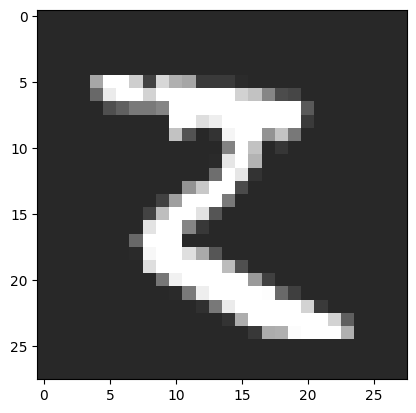

In [180]:
import numpy as np
import matplotlib.pyplot as plt

# np. flip image
mnist_digit_28x28_flipped = np.flip(mnist_digit_28x28, axis=1)
# show the image
plt.imshow(mnist_digit_28x28_flipped, cmap='gray', vmin=0, vmax=255)
plt.show()



### Hand-designed filters (SciPy)

**What the next code cell does**

1. Converts `mnist_digit_28x28` to a NumPy array.  
2. Applies five **3×3** filters with `scipy.signal.convolve2d` (`mode='valid'`).  
3. **Plots** a **2×3** grid: original MNIST digit + five **26×26** response maps.

**SciPy note:** `convolve2d` flips the kernel internally. We pre-flip with `np.flip(kernel)` so the stencil matches textbook/CNN-style correlation.

**What to notice:** Edge filters highlight strokes; blur smooths; sharpen increases contrast; Laplacian emphasizes rapid intensity changes.

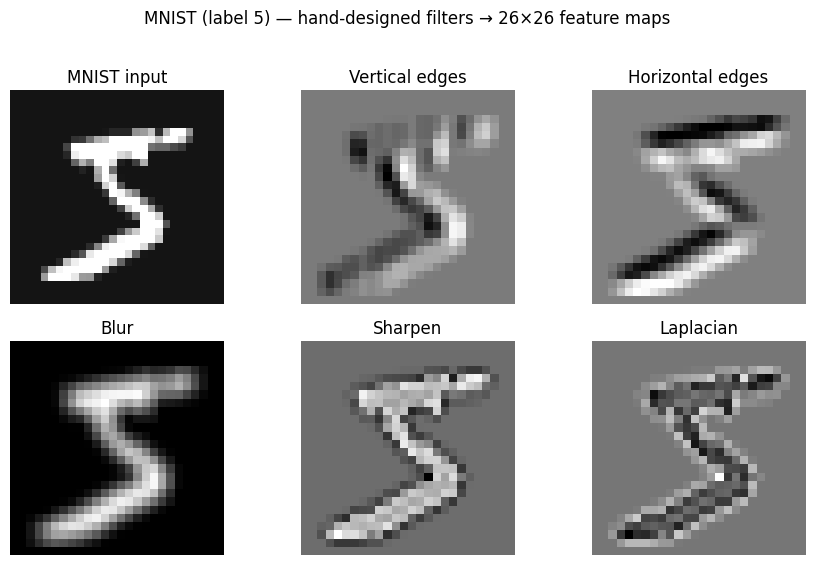

In [170]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

image = np.asarray(mnist_digit_28x28, dtype=np.float64)

filters = {
    'Vertical edges': [[1, 0, -1], [1, 0, -1], [1, 0, -1]],
    'Horizontal edges': [[1, 1, 1], [0, 0, 0], [-1, -1, -1]],
    'Blur': [[1 / 9.0] * 3 for _ in range(3)],
    'Sharpen': [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    'Laplacian': [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
}

maps = {}
for name, kernel in filters.items():
    k = np.asarray(kernel, dtype=np.float64)
    kern_for_conv = np.flip(k)
    maps[name] = signal.convolve2d(image, kern_for_conv, mode='valid')

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
titles = ['MNIST input'] + list(filters.keys())
grids = [mnist_digit_28x28] + [maps[n] for n in filters]

for ax, title, grid in zip(axes.flat, titles, grids):
    if title == 'MNIST input':
        ax.imshow(grid, cmap='gray', vmin=0, vmax=255)
    else:
        g = np.asarray(grid)
        ax.imshow(g, cmap='gray', vmin=float(g.min()), vmax=float(g.max()))
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(
    f'MNIST (label {mnist_label}) — hand-designed filters → 26×26 feature maps',
    y=1.02,
)
plt.tight_layout()
plt.show()

### Same filters with PyTorch `conv2d`

**Needs:** Setup (`mnist_digit_28x28`). Run the SciPy filters cell first if `matplotlib` is not imported yet.

**What the next code cell does**

1. Converts the MNIST digit to a PyTorch tensor shaped **(1, 1, 28, 28)** — batch and channel dimensions for `F.conv2d`.  
2. Applies the **same five 3×3 stencils** as the SciPy example.  
3. Plots the original digit plus five **26×26** response maps.

**PyTorch note:** `F.conv2d` does **not** flip the kernel the way `scipy.signal.convolve2d` does, so we pass the stencil as written.

**What to notice:** Output shapes and patterns should closely match the SciPy cell — same math, different library.


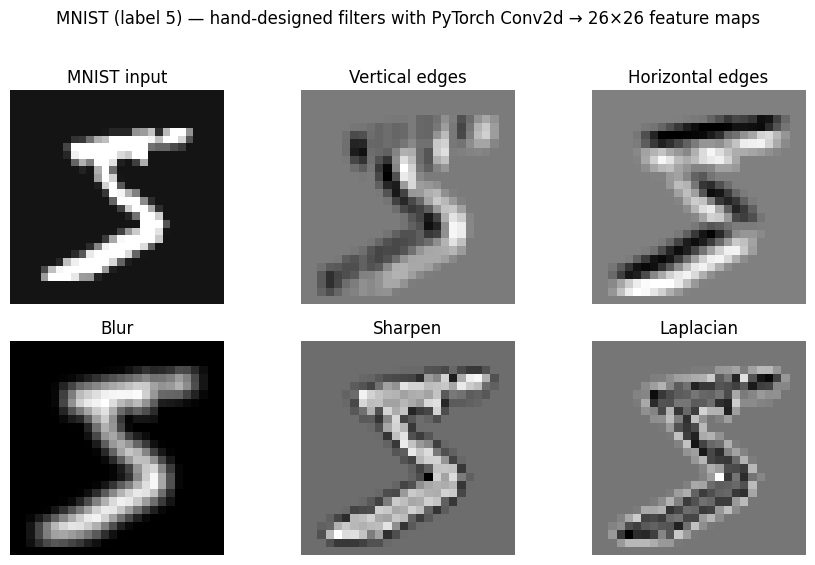

In [171]:
import torch
import torch.nn.functional as F

# Convert image to torch tensor and add batch/channel dimensions
image_torch = torch.tensor(mnist_digit_28x28, dtype=torch.float32).unsqueeze(0).unsqueeze(0)

filters_torch = {
    'Vertical edges': [[1, 0, -1], [1, 0, -1], [1, 0, -1]],
    'Horizontal edges': [[1, 1, 1], [0, 0, 0], [-1, -1, -1]],
    'Blur': [[1 / 9.0] * 3 for _ in range(3)],
    'Sharpen': [[0, -1, 0], [-1, 5, -1], [0, -1, 0]],
    'Laplacian': [[0, 1, 0], [1, -4, 1], [0, 1, 0]],
}

maps_torch = {}
for name, kernel in filters_torch.items():
    k_torch = torch.tensor(kernel, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    # PyTorch nn.functional.conv2d does NOT flip the kernel like scipy.signal.convolve2d
    result = F.conv2d(image_torch, k_torch)
    maps_torch[name] = result.squeeze().detach().numpy()

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
titles = ['MNIST input'] + list(filters_torch.keys())
grids = [mnist_digit_28x28] + [maps_torch[n] for n in filters_torch]

for ax, title, grid in zip(axes.flat, titles, grids):
    if title == 'MNIST input':
        ax.imshow(grid, cmap='gray', vmin=0, vmax=255)
    else:
        g = np.asarray(grid)
        ax.imshow(g, cmap='gray', vmin=float(g.min()), vmax=float(g.max()))
    ax.set_title(title)
    ax.axis('off')

plt.suptitle(
    f'MNIST (label {mnist_label}) — hand-designed filters with PyTorch Conv2d → 26×26 feature maps',
    y=1.02,
)
plt.tight_layout()
plt.show()


### Gaussian blur

**Needs:** Setup (`mnist_digit_28x28`). Run the SciPy filters cell first (it imports `numpy` and `matplotlib`).

**What this does:** Applies `scipy.ndimage.gaussian_filter` with `sigma=1` — a smooth blur that weights nearby pixels by distance.

**What to notice:** Try changing `sigma` to see stronger or weaker blur. Blur reduces noise but also softens fine detail (important for crack-like features).


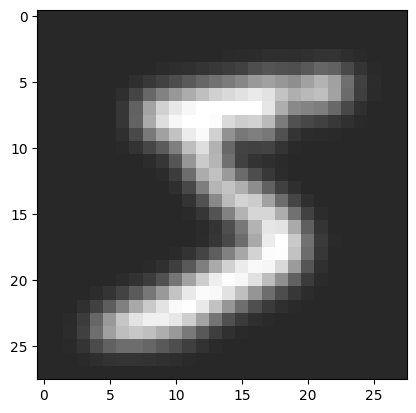

In [ ]:
from scipy.ndimage import gaussian_filter

# show gaussian blur
#change the sigma to see how the blur changes
mnist_digit_28x28_blur = gaussian_filter(mnist_digit_28x28, sigma=1)
# show the image
plt.imshow(mnist_digit_28x28_blur, cmap='gray', vmin=0, vmax=255)
plt.show()

### Binary thresholding

**Needs:** Setup (`mnist_digit_28x28`).

**What this does:** Converts the grayscale digit to **black and white** — pixels ≥ 128 become 255, others become 0.

**What to notice:** Thresholding throws away intensity gradations. It can simplify segmentation masks but may erase subtle defects if the threshold is wrong.


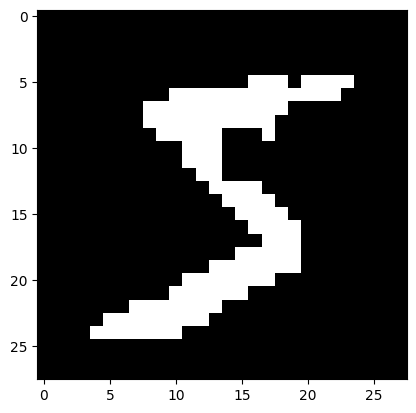

In [185]:
# Apply thresholding: pixels >= 128 become 255, others become 0
threshold = 128
binary_image = (mnist_digit_28x28 > threshold).astype(np.uint8) * 255
# show the image
plt.imshow(binary_image, cmap='gray', vmin=0, vmax=255)
plt.show()



### Convolution with padding and stride (PyTorch)

**Needs:** Setup (`mnist_digit_28x28`). Run an earlier plotting cell first if `matplotlib` is not imported yet.

**What the next code cell does**

1. Builds a **3×3** edge-emphasis kernel and runs `F.conv2d` with **`stride=2`** and **`padding=1`**.  
2. Prints the **output shape** and plots the result.

| Parameter | Effect in this example |
| --------- | ---------------------- |
| **Padding** | Adds a border so edge pixels are not dropped as quickly |
| **Stride** | Moves the filter two pixels at a time → **smaller** output grid |

**What to notice:** Change `stride` and `padding` and watch how output height/width change — the same ideas appear inside every CNN stack.


Convolved result shape (with stride=2, padding=1): (14, 14)


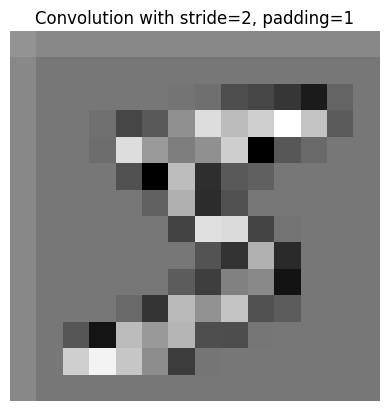

In [ ]:


# Example of convolution with padding and stride in PyTorch

import torch
import torch.nn.functional as F

# Convert the numpy array to a torch tensor and add batch and channel dimensions
img_tensor = torch.tensor(mnist_digit_28x28, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # shape (1,1,28,28)

# Make a simple 3x3 edge detection filter/kernel
edge_kernel = torch.tensor([[[[-1, -1, -1],
                              [-1,  8, -1],
                              [-1, -1, -1]]]], dtype=torch.float32)

# Convolve with stride=2 and padding=1
# feel free to change the stride and padding to see how the convolution result changes
conv_out = F.conv2d(img_tensor, edge_kernel, stride=2, padding=1)

# Remove unnecessary dimensions for display
conv_result = conv_out.squeeze().detach().numpy()

print("Convolved result shape (with stride=2, padding=1):", conv_result.shape)
plt.imshow(conv_result, cmap='gray')
plt.title('Convolution with stride=2, padding=1')
plt.axis('off')
plt.show()



## Max pooling

**Needs:** Setup (`mnist_digit_28x28`). Also run the convolution cell first if you want `matplotlib` already imported (this cell uses `plt`).

**Key idea:** **2×2 max pooling** (stride 2, non-overlapping) replaces each block of four pixels with the **maximum** value. Strong responses survive; spatial size shrinks.

| Before | After (this example) |
| ------ | -------------------- |
| 28×28 MNIST digit | 14×14 pooled grid |

Pooling reduces compute and gives a little translation tolerance. In PyTorch: `nn.MaxPool2d(2)`.

**What the next code cell does**

1. Defines `max_pool_2x2` on nested lists (same logic as the chapter).  
2. Pools `mnist_digit_28x28` and prints output size plus a **preview** of the first rows.  
3. **Plots** side by side: **original** vs **max-pooled** image so you can compare resolution.

After 2×2 max pool: 14 × 14
First 4 rows (preview):
array([[ 40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,
         40.,  40.,  40.],
       [ 40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,  40.,
         40.,  40.,  40.],
       [ 40.,  40.,  40.,  40.,  40.,  40.,  58.,  58., 176., 215., 295.,
        287.,  40.,  40.],
       [ 40.,  40.,  40.,  89., 293., 293., 293., 293., 293., 265., 293.,
        235.,  40.,  40.]], dtype=float32)


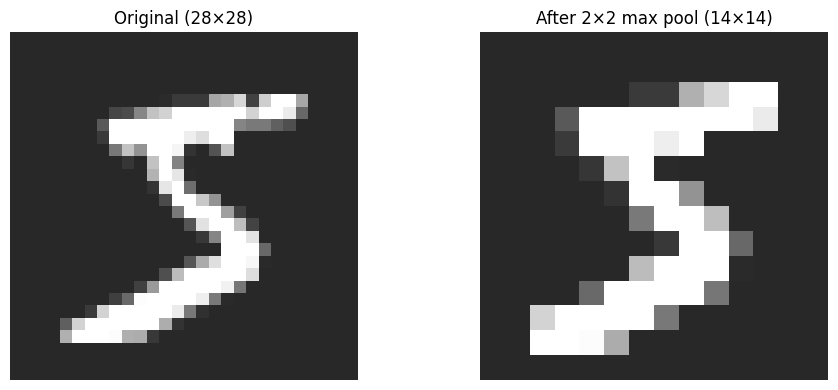

In [186]:
import torch
import torch.nn.functional as F

# Convert the numpy array to a torch tensor and add batch/channel dims
mnist_tensor = torch.tensor(mnist_digit_28x28, dtype=torch.float32).unsqueeze(0).unsqueeze(0)  # shape (1,1,28,28)

# Apply 2x2 max pooling with stride 2
pooled_tensor = F.max_pool2d(mnist_tensor, kernel_size=2, stride=2)

# Remove unnecessary dimensions and convert back to numpy for display/printing
pooled = pooled_tensor.squeeze().numpy()

print('After 2×2 max pool:', pooled.shape[0], '×', pooled.shape[1])
print('First 4 rows (preview):')
pprint(pooled[:4])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(mnist_digit_28x28, cmap='gray', vmin=0, vmax=255)
axes[0].set_title('Original (28×28)')
axes[1].imshow(pooled, cmap='gray', vmin=0, vmax=255)
axes[1].set_title('After 2×2 max pool (14×14)')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

## Choosing a computer vision task type

Not every image problem is **classification**. The chapter maps **business questions** to task types:

| Question style | Typical task |
| -------------- | ------------ |
| One label per image | **Classification** |
| Boxes + labels | **Object detection** |
| Label per pixel / region | **Segmentation** |

The next cell is a small lookup table for weld-style inspection questions.

**What to look for:** Read each question on the left and confirm the suggested task type on the right matches how you would label data and measure success.

In [173]:
vision_needs = {
    'Does this image contain a defect?': 'classification',
    'What type of defect is shown?': 'classification',
    'Where is the defect roughly located?': 'object detection',
    'How many defects are present?': 'object detection or instance segmentation',
    'What is the exact defect area?': 'segmentation',
    'Which pixels are crack vs. background?': 'segmentation',
}

pprint(vision_needs)

{'Does this image contain a defect?': 'classification',
 'How many defects are present?': 'object detection or instance segmentation',
 'What is the exact defect area?': 'segmentation',
 'What type of defect is shown?': 'classification',
 'Where is the defect roughly located?': 'object detection',
 'Which pixels are crack vs. background?': 'segmentation'}


## Architecture tradeoffs

After you pick a **task type**, you pick a **model family**. No single architecture wins on every metric — teams trade off accuracy, speed, memory, annotation cost, and interpretability.

The next cell summarizes families from the chapter (ResNet, EfficientNet, YOLO, Faster R-CNN, U-Net, Mask R-CNN).

**What to look for:** For each entry, note **task**, **strength**, and **tradeoff**. Use this when brainstorming a pilot — not as a rigid rule.

In [174]:
architecture_examples = {
    'ResNet': {
        'task': 'classification',
        'strength': 'strong baseline with skip connections',
        'tradeoff': 'larger versions can be computationally expensive',
    },
    'EfficientNet': {
        'task': 'classification',
        'strength': 'good accuracy-to-compute tradeoff',
        'tradeoff': 'more complex design',
    },
    'YOLO': {
        'task': 'object detection',
        'strength': 'fast one-stage detection',
        'tradeoff': 'may trade some accuracy for speed',
    },
    'Faster R-CNN': {
        'task': 'object detection',
        'strength': 'often accurate localization',
        'tradeoff': 'usually slower than one-stage detectors',
    },
    'U-Net': {
        'task': 'segmentation',
        'strength': 'strong for pixel masks and smaller datasets',
        'tradeoff': 'can require memory for large images',
    },
    'Mask R-CNN': {
        'task': 'instance segmentation',
        'strength': 'separates individual object masks',
        'tradeoff': 'heavier and needs mask annotations',
    },
}

pprint(architecture_examples)

{'EfficientNet': {'strength': 'good accuracy-to-compute tradeoff',
                  'task': 'classification',
                  'tradeoff': 'more complex design'},
 'Faster R-CNN': {'strength': 'often accurate localization',
                  'task': 'object detection',
                  'tradeoff': 'usually slower than one-stage detectors'},
 'Mask R-CNN': {'strength': 'separates individual object masks',
                'task': 'instance segmentation',
                'tradeoff': 'heavier and needs mask annotations'},
 'ResNet': {'strength': 'strong baseline with skip connections',
            'task': 'classification',
            'tradeoff': 'larger versions can be computationally expensive'},
 'U-Net': {'strength': 'strong for pixel masks and smaller datasets',
           'task': 'segmentation',
           'tradeoff': 'can require memory for large images'},
 'YOLO': {'strength': 'fast one-stage detection',
          'task': 'object detection',
          'tradeoff': 'may trade some

## Mini workflow example

This ties **goal → task → architecture → loss → metric → tradeoff** into one dictionary for a hypothetical crack-segmentation use case. Real projects document the same decisions before training.

**What to look for:** Check that `task_type`, `starting_architecture`, and `starting_loss` are consistent with each other and with how you would annotate data.

In [175]:
use_case = {
    'goal': 'Find each visible crack and estimate its area',
    'task_type': 'segmentation',
    'starting_architecture': 'U-Net',
    'starting_loss': 'cross entropy plus dice loss',
    'metric_to_watch': 'crack recall and Dice score',
    'main_tradeoff': 'more annotation effort, but better pixel-level measurements',
}

pprint(use_case)

{'goal': 'Find each visible crack and estimate its area',
 'main_tradeoff': 'more annotation effort, but better pixel-level measurements',
 'metric_to_watch': 'crack recall and Dice score',
 'starting_architecture': 'U-Net',
 'starting_loss': 'cross entropy plus dice loss',
 'task_type': 'segmentation'}


## Tiny PyTorch CNN skeleton

**Needs:** `torch` installed.

This is **not** full training — it shows how **learned** convolutional layers stack in code and how tensor **shapes** change. Compare to the earlier section: there we **plotted fixed filters**; here **`nn.Conv2d` weights would be learned** if you ran a training loop (see assessment / CV labs).

**Shape flow (batch of 4, MNIST-sized 28×28 grayscale):**

| Step | Shape |
| ---- | ----- |
| Input | `(4, 1, 28, 28)` |
| Conv 1 + ReLU | `(4, 16, 28, 28)` |
| MaxPool 2×2 | `(4, 16, 14, 14)` |
| Conv 2 + ReLU | `(4, 32, 14, 14)` |
| MaxPool 2×2 | `(4, 32, 7, 7)` |
| Flatten + Linear | `(4, 10)` logits |

**What the next code cell does**

1. Defines `TinyCNN` with two conv blocks and a linear classifier.  
2. Runs a **random** batch through the model (no training).  
3. Prints the module structure and **input / output shapes**.

**Optional extension:** After training in another notebook, you could visualize **learned** `conv1` weights with `model.features[0].weight` — that is the “plot learned filters” step in a full lab.

In [176]:
import torch
import torch.nn as nn

class TinyCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Linear(32 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, start_dim=1)
        return self.classifier(x)

model = TinyCNN()
example_batch = torch.randn(4, 1, 28, 28)
logits = model(example_batch)

print(model)
print('Input shape:', tuple(example_batch.shape))
print('Output logits shape:', tuple(logits.shape))

TinyCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Linear(in_features=1568, out_features=10, bias=True)
)
Input shape: (4, 1, 28, 28)
Output logits shape: (4, 10)


## Transfer learning with a pretrained model

**Needs:** `torch`, `torchvision`, `PIL`, `requests`, and network access (downloads a sample image and ImageNet labels).

**Key idea:** You can start from a model **already trained** on a large dataset (here: **ResNet-18** on ImageNet) instead of training every layer from scratch. That is common when you have limited labeled inspection images.

This section downloads a photo, preprocesses it the ImageNet way, runs inference, and prints **top-5** class probabilities.


**What the next code cell does**

1. Downloads a sample RGB image and loads **pretrained ResNet-18**.  
2. Resizes, center-crops to **224×224**, converts to a tensor, and applies **ImageNet mean/std normalization**.  
3. Runs a forward pass and prints the **top-5** predicted ImageNet classes.

**What to notice:** Preprocessing must match what the pretrained model expects. A mismatch in size or normalization hurts accuracy even with a strong backbone.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5528543].


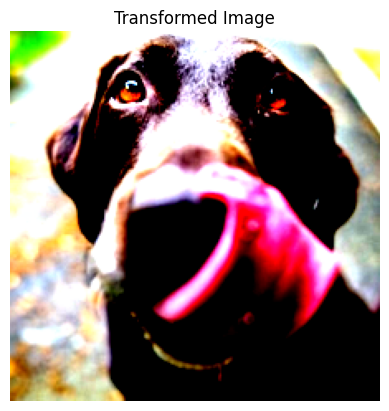

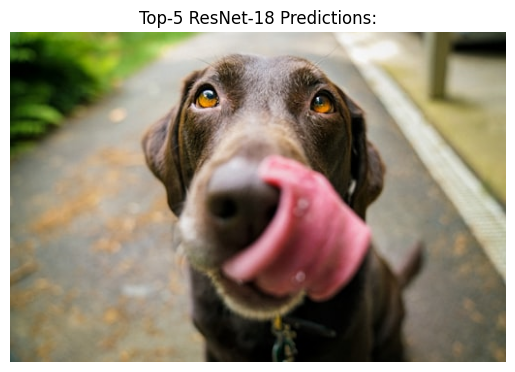

German short-haired pointer: 73.56%
bluetick: 11.21%
Labrador retriever: 5.87%
Weimaraner: 3.12%
Chesapeake Bay retriever: 1.29%


In [191]:
import torchvision.models as models
import torch
import torchvision.transforms as transforms
from PIL import Image
import requests
import matplotlib.pyplot as plt

img_url = "https://images.unsplash.com/photo-1518717758536-85ae29035b6d?auto=format&fit=crop&w=512&q=80"
img_path = "example_imagenet.jpg"
r = requests.get(img_url, stream=True)
with open(img_path, 'wb') as f:
    for chunk in r.iter_content(1024):
        f.write(chunk)

resnet18 = models.resnet18(pretrained=True)
resnet18.eval()

preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

img = Image.open(img_path).convert('RGB')
input_tensor = preprocess(img).unsqueeze(0)

plt.imshow(input_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy())
plt.axis('off')
plt.title('Transformed Image')
plt.show()

with torch.no_grad():
    output = resnet18(input_tensor)

LABELS_URL = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
labels = requests.get(LABELS_URL).text.strip().split('\n')

probabilities = torch.nn.functional.softmax(output[0], dim=0)
top5_prob, top5_catid = torch.topk(probabilities, 5)

plt.imshow(img)
plt.axis('off')
plt.title('Top-5 ResNet-18 Predictions:')
plt.show()

for i in range(top5_prob.size(0)):
    print(f"{labels[top5_catid[i]]}: {top5_prob[i].item()*100:.2f}%")


### Visualize learned feature maps (ResNet-18 `conv1`)

**Needs:** Run the ResNet cell above first (`resnet18`, `input_tensor`).

**What the next code cell does**

1. Registers a **forward hook** on the first convolutional layer (`conv1`).  
2. Runs the preprocessed image through the model.  
3. Plots the first **six** feature maps from that layer.

**What to notice:** Unlike the hand-designed filters earlier, these responses come from **weights learned on ImageNet** — different maps highlight different low-level patterns (edges, color blobs, textures).


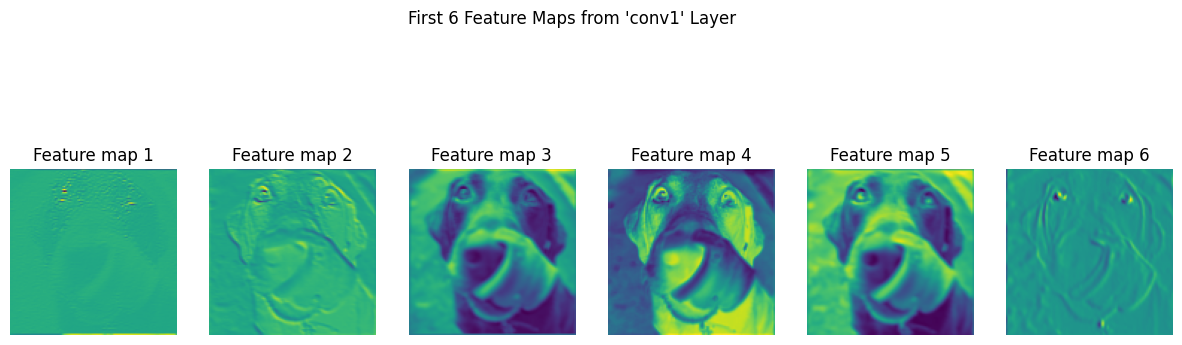

In [189]:
# Visualize feature maps from the first convolutional layer of ResNet-18

def visualize_feature_maps(model, img_tensor, layer_name='conv1', num_maps=6):
    # Get the specific layer
    layer = dict([*model.named_children()])[layer_name]
    activation = {}
    
    def hook_fn(module, input, output):
        activation['feature_maps'] = output.detach()
        
    hook = layer.register_forward_hook(hook_fn)
    with torch.no_grad():
        model(img_tensor)
    
    # Get feature maps (output of selected layer)
    feature_maps = activation['feature_maps'][0]  # Remove batch dimension
    
    plt.figure(figsize=(15, 5))
    for i in range(num_maps):
        plt.subplot(1, num_maps, i+1)
        plt.imshow(feature_maps[i].cpu(), cmap='viridis')
        plt.axis('off')
        plt.title(f'Feature map {i+1}')
    plt.suptitle(f"First {num_maps} Feature Maps from '{layer_name}' Layer")
    plt.show()
    hook.remove()

# Call the visualization function
visualize_feature_maps(resnet18, input_tensor, layer_name='conv1', num_maps=6)